In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from ipynb.fs.defs.functions import top_bottom, top_bottom_split_double, top_bottom_split_triple, find_outliers_iqr, read_nrw_map

In [2]:
# Einlesen
df = pd.read_csv("../data/processed/master_2024.csv", sep=",", encoding="UTF-8")
df.columns

Index(['Name', 'Typ 1', 'Typ 2', 'ROR', 'erz. Hilfen pro 10000',
       '35a Hilfen pro 10000', 'Überörtlicher Träger', 'Bevölkerung 6 bis 20',
       'Anteil Kinder a.d. Gesamtbev.', 'SGB II-Quote', 'Kinderarztdichte',
       'KJP-Dichte', 'Bildungsindex', 'Bevölkerungsdichte', 'Typ'],
      dtype='object')

In [3]:
s = df["35a Hilfen pro 10000"]

desc = s.describe()
iqr = desc["75%"] - desc["25%"]
span = desc["max"] - desc["min"]
cv = desc["std"] / desc["mean"]

summary = {
    "mean": desc["mean"],
    "median": desc["50%"],
    "std": desc["std"],
    "IQR": iqr,
    "span": span,
    "IQR/span": iqr / span,
    "CV": cv
}

pd.Series(summary).round(3)

mean        182.736
median      174.000
std          66.416
IQR          85.000
span        257.000
IQR/span      0.331
CV            0.363
dtype: float64

In [4]:
top_bottom(df, "35a Hilfen pro 10000", n=5)


Top 5 (hÃ¶chste Werte):
                   Name  35a Hilfen pro 10000
43                 Köln                   326
2     Ennepe-Ruhr-Kreis                   306
52               Aachen                   301
1                 Düren                   301
46  Mülheim an der Ruhr                   286

Bottom 5 (niedrigste Werte):
             Name  35a Hilfen pro 10000
36     Düsseldorf                    69
18      Steinfurt                    74
38  Gelsenkirchen                    77
29      Warendorf                    93
4         Herford                    94


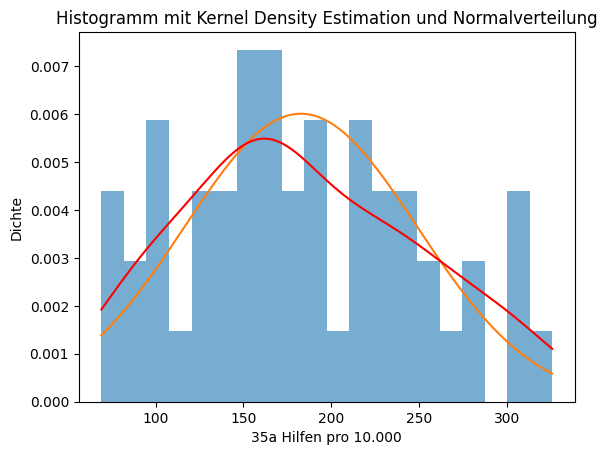

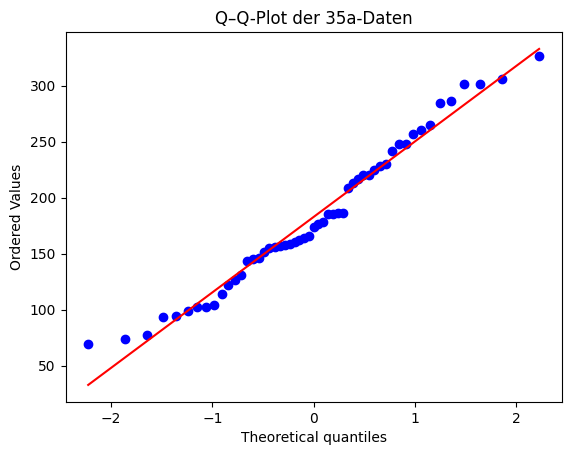

In [5]:
x = df["35a Hilfen pro 10000"].to_numpy()

plt.figure()
plt.hist(x, bins=20, density=True, alpha=0.6)

xx = np.linspace(x.min(), x.max(), 200)

mu = x.mean()
sigma = x.std(ddof=1) # Degrees fo Freedom n-1 da Strichprobe, nicht Grundgesamtheit
plt.plot(xx, stats.norm.pdf(xx, mu, sigma))

# bandwith bei stardard gelassen, o.5 liefert ähnlcihe ergebnisse, höhere werte drücken die
kde = stats.gaussian_kde(x)
plt.plot(xx, kde(xx), color="red")


plt.xlabel("35a Hilfen pro 10.000")
plt.ylabel("Dichte")
plt.title("Histogramm mit Kernel Density Estimation und Normalverteilung")
plt.show()


plt.figure()
stats.probplot(x, dist="norm", plot=plt)
plt.title("Q–Q-Plot der 35a-Daten")
plt.show()

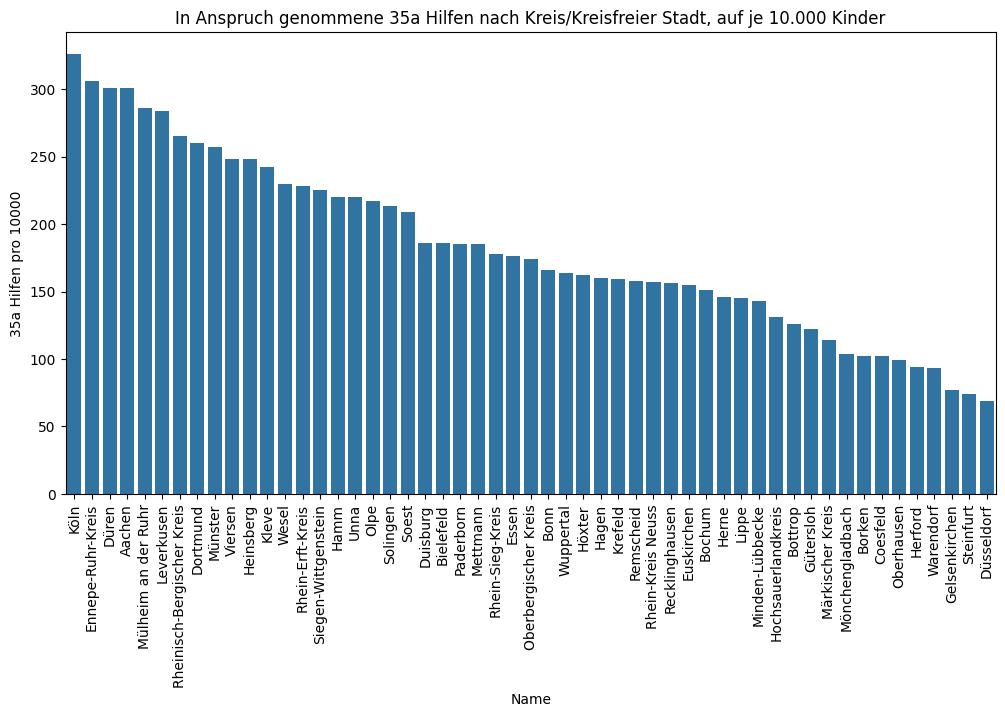

In [6]:
plt.figure(figsize=(12,6))
sns.barplot(data=df.sort_values('35a Hilfen pro 10000', ascending=False),
            x='Name', y='35a Hilfen pro 10000')
plt.xticks(rotation=90)
plt.title("In Anspruch genommene 35a Hilfen nach Kreis/Kreisfreier Stadt, auf je 10.000 Kinder")
plt.show()

In [7]:
mask = find_outliers_iqr(s)

print(f"Anzahl Ausreißer: {mask.sum()}")

Anzahl Ausreißer: 0


0             Hochsauerlandkreis
1                      Heinsberg
2                Mönchengladbach
3               Rhein-Sieg-Kreis
4     Rheinisch-Bergischer Kreis
5                        Bottrop
6              Ennepe-Ruhr-Kreis
7              Mülheim a.d. Ruhr
8           Oberbergischer Kreis
9               Märkischer Kreis
10                       Krefeld
11                    Leverkusen
12                        Borken
13                    Euskirchen
14                        Höxter
15                     Paderborn
16                       Münster
17                     Remscheid
18                    Düsseldorf
19                          Hamm
20                      Dortmund
21                    Oberhausen
22                     Steinfurt
23                         Soest
24               Minden-Lübbecke
25           Städteregion Aachen
26                         Herne
27                         Hagen
28                 Gelsenkirchen
29                         Kleve
30        

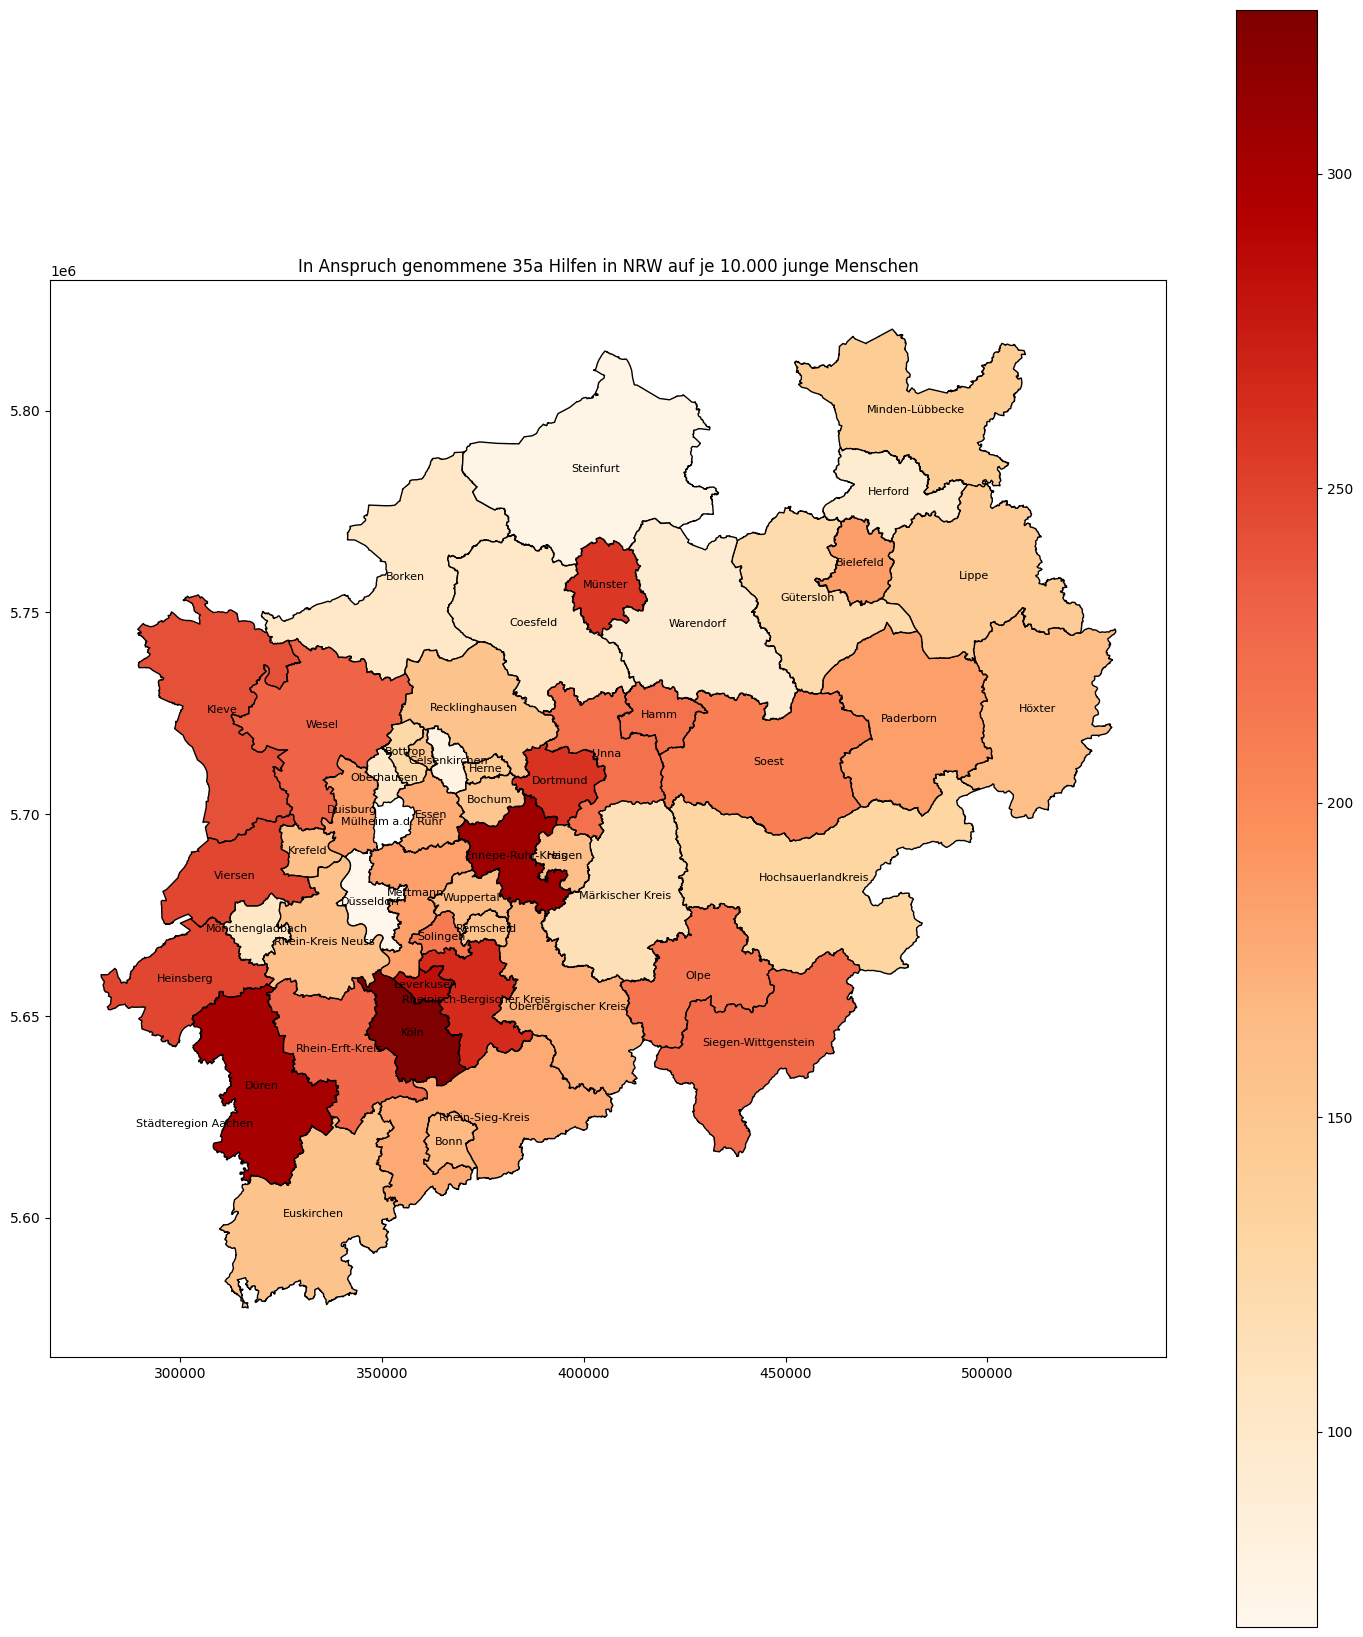

In [8]:
# Visualisierung
nrw = read_nrw_map(df)
fig, ax = plt.subplots(1, 1, figsize=(18, 21))
nrw.plot(column="35a Hilfen pro 10000", ax=ax, legend=True, cmap="OrRd", edgecolor="black")

for idx, row in nrw.iterrows():
    if row['geometry'].geom_type == 'Polygon':
        x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    else:  # MultiPolygon
        x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    ax.text(x, y, row['GN'], fontsize=8, ha='center', va='center')

ax.set_title("In Anspruch genommene 35a Hilfen in NRW auf je 10.000 junge Menschen")
plt.show()